In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pywt

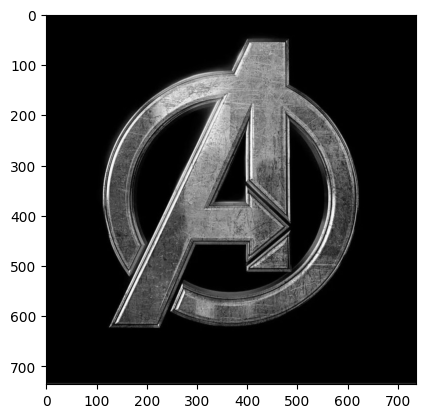

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('doomsday.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.show()

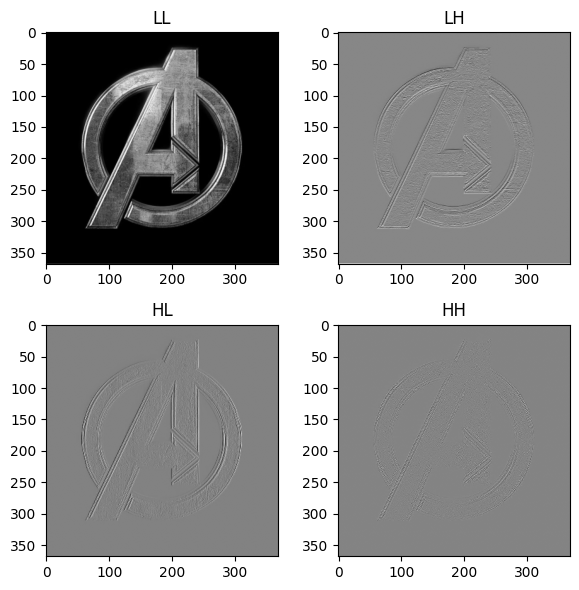

In [24]:
LL, (LH, HL, HH) = pywt.dwt2(gray, 'haar')

plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.imshow(LL, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(LH, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(HL, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(HH, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

In [26]:
kernel = np.ones((3,3), np.uint8)

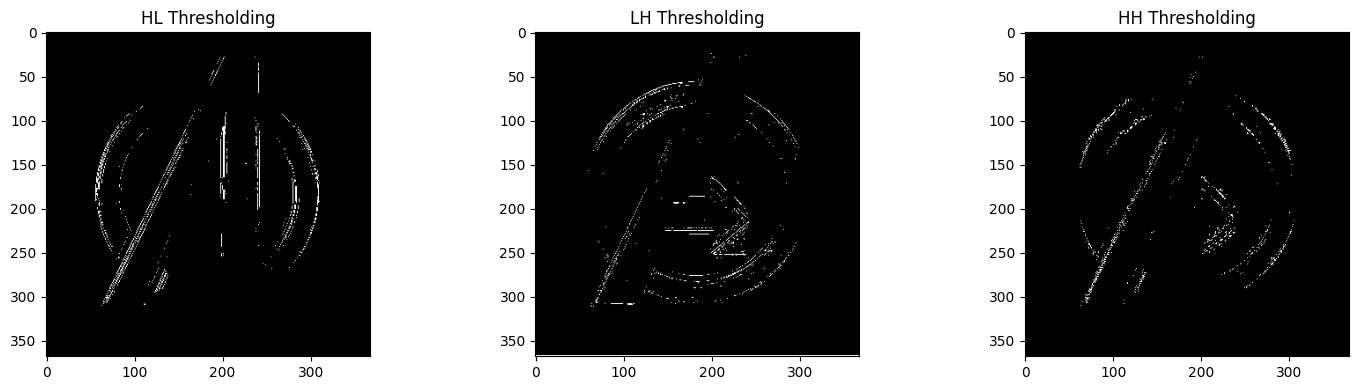

In [42]:
threshold = 100

LH_u8 = cv.normalize(np.abs(LH), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
HL_u8 = cv.normalize(np.abs(HL), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
HH_u8 = cv.normalize(np.abs(HH), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

_, LH_th = cv.threshold(LH_u8, threshold, 255, cv.THRESH_BINARY)
_, HL_th = cv.threshold(HL_u8, threshold, 255, cv.THRESH_BINARY)
_, HH_th = cv.threshold(HH_u8, threshold, 255, cv.THRESH_BINARY)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(HL_th, cmap='gray')
plt.title('HL Thresholding')

plt.subplot(1,3,2)
plt.imshow(LH_th, cmap='gray')
plt.title('LH Thresholding')

plt.subplot(1,3,3)
plt.imshow(HH_th, cmap='gray')
plt.title('HH Thresholding')

plt.tight_layout()
plt.show()

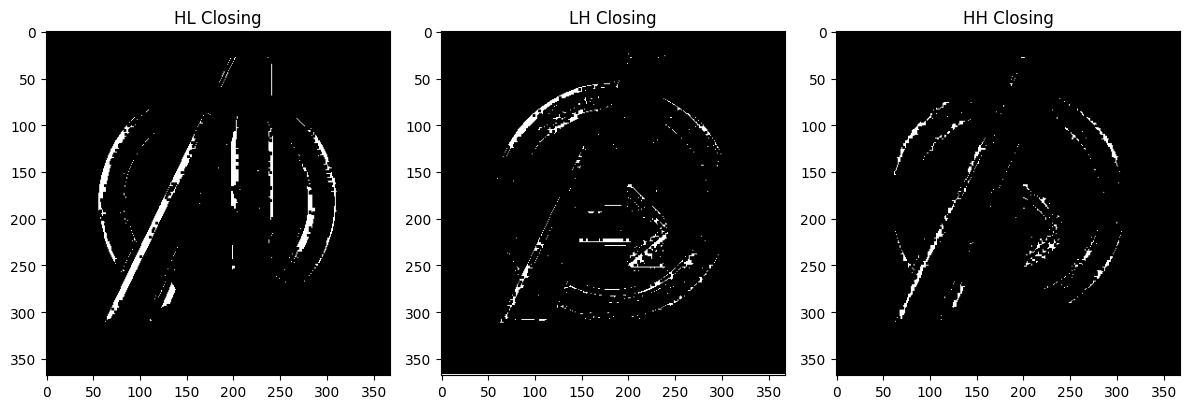

In [ ]:
kernel = np.ones((3,3), np.uint8)

HL_close = cv.morphologyEx(HL_th, cv.MORPH_CLOSE, kernel)
LH_close = cv.morphologyEx(LH_th, cv.MORPH_CLOSE, kernel)
HH_close = cv.morphologyEx(HH_th, cv.MORPH_CLOSE, kernel)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(HL_close, cmap='gray')
plt.title('HL Closing')

plt.subplot(1,3,2)
plt.imshow(LH_close, cmap='gray')
plt.title('LH Closing')

plt.subplot(1,3,3)
plt.imshow(HH_close, cmap='gray')
plt.title('HH Closing')

plt.tight_layout()
plt.show()

In [43]:
rek1 = pywt.idwt2(
    (LL, (LH, HL, HH)),
    'haar'
)

In [44]:
LL_zero = np.zeros_like(LL)

rek2 = pywt.idwt2(
    (LL_zero, (LH, HL, HH)),
    'haar'
)

In [45]:
rek3 = pywt.idwt2(
    (
        LL_zero,
        (
            LH_close.astype(float),
            HL_close.astype(float),
            HH_close.astype(float)
        )
    ),
    'haar'
)

In [46]:
rek4 = pywt.idwt2(
    (
        LL,
        (
            LH_close.astype(float),
            HL_close.astype(float),
            HH_close.astype(float)
        )
    ),
    'haar'
)

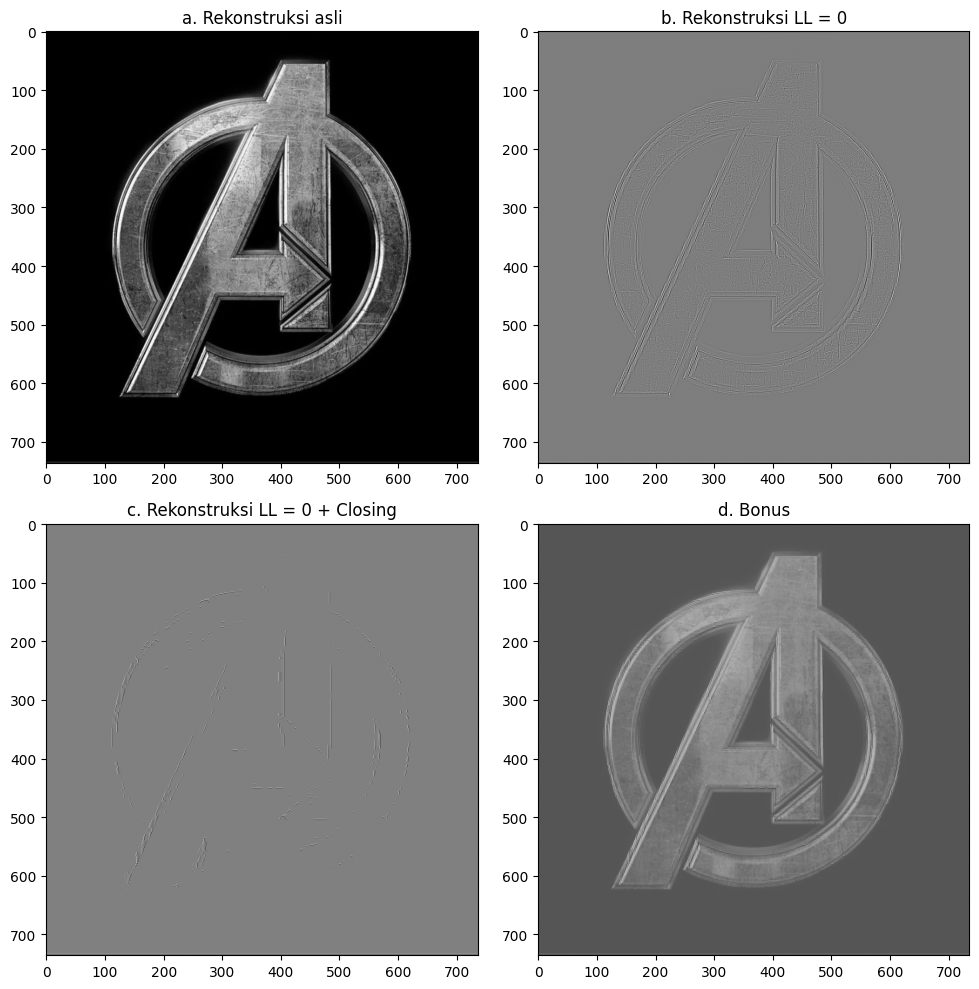

In [52]:
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.imshow(rek1, cmap='gray')
plt.title('a. Rekonstruksi asli')

plt.subplot(2,2,2)
plt.imshow(rek2, cmap='gray')
plt.title('b. Rekonstruksi LL = 0')

plt.subplot(2,2,3)
plt.imshow(rek3, cmap='gray')
plt.title('c. Rekonstruksi LL = 0 + Closing')

plt.subplot(2,2,4)
plt.imshow(rek4, cmap='gray')
plt.title('d. Bonus')

plt.tight_layout()
plt.show()

Analisis 

a. Rekonstruksi Normal : Gambar hasil hampir sama dengan citra asli karena seluruh subband digunakan.
b. LL = 0 : Informasi frekuensi rendah hilang sehingga hanya tersisa detail tepi dan tekstur.
c. LL = 0 + Closing : Detail tepi masih terlihat tetapi lebih menyambung karena efek operasi closing.
d. Bonus : Menggabungkan informasi LL asli dengan detail hasil closing sehingga objek terlihat lebih jelas dan noise berkurang.